# ICRA2026
Files: Pre-Post-Surveys-Together.xlsx


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.colors import TwoSlopeNorm
from scipy import stats
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Path to the Excel file
file_path = r'c:\Users\gizem\Desktop\ARSO\PRE-POST-SURVEY-TOGETHER.xlsx'
 
LIKERT_MAP = {
    'Completely agree':    7,
    'Agree':               6,
    'Partly agree':        5,
    'No opinion':          4,
    'Partly disagree':     3,
    'Partly Disagree':     3,   # capitalisation variant in the data
    'Disagree':            2,
    'Completely disagree': 1,
}
 
Q_LABELS = [
    "Q1 Amuses me",
    "Q2 Scares me",
    "Q3 Unemployment",
    "Q4 New jobs",
    "Q5 Life quality",
    "Q6 HRC preference",
    "Q7 Humans better",
    "Q8 Robots better",
    "Q9 Destroy humankind",
]

# Q_DIRECTION = {
#     "Q1 Amuses me":         ("good",    "↑ more enthusiasm"),
#     "Q2 Scares me":         ("bad",     "↑ more fear"),
#     "Q3 Unemployment":      ("bad",     "↑ more concern"),
#     "Q4 New jobs":          ("good",    "↑ more optimism"),
#     "Q5 Life quality":      ("good",    "↑ more optimism"),
#     "Q6 HRC preference":    ("good",    "↑ more preference for HRC"),
#     "Q7 Humans better":     ("neutral", "↑ stronger human-task belief"),
#     "Q8 Robots better":     ("neutral", "↑ stronger robot-task belief"),
#     "Q9 Destroy humankind": ("bad",     "↑ more fear"),
# }

Q_DIRECTION = {
    "Q1 Amuses me":         "good",
    "Q2 Scares me":         "bad",
    "Q3 Unemployment":      "bad",
    "Q4 New jobs":          "good",
    "Q5 Life quality":      "good",
    "Q6 HRC preference":    "good",
    "Q7 Humans better":     "neutral",
    "Q8 Robots better":     "neutral",
    "Q9 Destroy humankind": "bad",
}
 
PARAM_COLS = [
    'age', 'sex', 'current_gaming', 'past_gaming', 'programming',
    'robot_familiarity', 'robot_proximity', 'robot_industrial', 'robot_interest',
]

pre_raw  = pd.read_excel(file_path, sheet_name='PRE')
post_raw = pd.read_excel(file_path, sheet_name='POST')

In [3]:
# PRE:  col 0 = exp_id, cols 1–9 = user params, cols 10–18 = questions
# POST: col 0 = exp_id, cols 12–20 = comparative questions
pre_raw.columns = ['exp_id'] + PARAM_COLS + Q_LABELS + ['nps1', 'nps2']
post_raw.rename(columns={post_raw.columns[0]: 'exp_id'}, inplace=True)
 
post_q_raw = post_raw.iloc[:, 12:21].copy()
post_q_raw.columns = Q_LABELS
post_q_raw['exp_id'] = post_raw['exp_id']

In [4]:
# Merge on Experiment ID — this gives exactly the matched pairs
merged = pre_raw[['exp_id'] + Q_LABELS].merge(
    post_q_raw, on='exp_id', suffixes=('_pre', '_post')
)
 
print(f"  Matched participants: n = {len(merged)}")
assert len(merged) == 31, f"Expected 31, got {len(merged)} — check your data file."

  Matched participants: n = 31


STEP 2a — ENCODE LIKERT RESPONSES TO 1–7 INTEGERS

In [5]:
def encode_questions(df, labels, suffix):
    cols = [f'{q}{suffix}' for q in labels]
    out  = df[cols].replace(LIKERT_MAP).apply(pd.to_numeric, errors='coerce')
    out.columns = labels
    return out
 
pre_q  = encode_questions(merged, Q_LABELS, '_pre')
post_q = encode_questions(merged, Q_LABELS, '_post')
 
# Verify encoding worked (no NaNs, values in 1–7)
assert pre_q.isna().sum().sum() == 0,  "NaNs in PRE — check LIKERT_MAP for unmapped strings"
assert post_q.isna().sum().sum() == 0, "NaNs in POST — check LIKERT_MAP for unmapped strings"
assert pre_q.min().min() >= 1 and pre_q.max().max() <= 7,  "PRE values out of 1–7 range"
assert post_q.min().min() >= 1 and post_q.max().max() <= 7, "POST values out of 1–7 range"


STEP 2b — COMPUTE SHIFT SCORES  (POST − PRE)

- Positive shift = moved toward agreement after the experiment
- Negative shift = moved toward disagreement
- Range: −6 to +6

In [6]:
shift = post_q - pre_q

### DESCRIPTIVE STATISTICS TABLE


In [7]:
print()
print("=" * 85)
print("SHIFT SCORES  (POST − PRE,  Likert 1–7,  n=31)")
print("'Positive toward HRC' column shows what a positive shift means per question")
print("=" * 85)
print(f"\n{'Question':<24} {'Dir':>5}  {'mean Δ':>7} {'med Δ':>7} {'sd':>6}  "
      f"{'%pos':>5}  {'%neg':>5}  {'%zero':>6}  {'Positive shift means'}") 
print("-" * 85)
 
for q in Q_LABELS:
    s          = shift[q]
    direction = Q_DIRECTION[q]
    dir_symbol = "↑✓" if direction == "good" else "↑✗" if direction == "bad" else "↑~"
    pos        = (s > 0).mean() * 100
    neg        = (s < 0).mean() * 100
    zero       = (s == 0).mean() * 100
    print(f"  {q:<22} {dir_symbol:>5}  {s.mean():>+7.3f} {s.median():>+7.1f} "
          f"{s.std():>6.3f}  {pos:>4.0f}%  {neg:>4.0f}%  {zero:>5.0f}%")
 
print()
print("Dir legend:  ↑✓ = positive shift is good for HRC acceptance")
print("             ↑✗ = positive shift is bad  (fear/concern question — expect negative shift)")
print("             ↑~ = neutral framing (task complementarity)")


SHIFT SCORES  (POST − PRE,  Likert 1–7,  n=31)
'Positive toward HRC' column shows what a positive shift means per question

Question                   Dir   mean Δ   med Δ     sd   %pos   %neg   %zero  Positive shift means
-------------------------------------------------------------------------------------
  Q1 Amuses me              ↑✓   +0.645    +1.0  1.305    52%    13%     35%
  Q2 Scares me              ↑✗   -0.387    +0.0  0.919     6%    32%     61%
  Q3 Unemployment           ↑✗   -0.387    +0.0  1.116    13%    39%     48%
  Q4 New jobs               ↑✓   +0.065    +0.0  0.929    29%    16%     55%
  Q5 Life quality           ↑✓   +0.581    +0.0  1.232    39%    10%     52%
  Q6 HRC preference         ↑✓   +0.258    +0.0  1.264    39%    23%     39%
  Q7 Humans better          ↑~   +0.129    +0.0  1.648    29%    29%     42%
  Q8 Robots better          ↑~   +0.419    +0.0  1.177    39%    16%     45%
  Q9 Destroy humankind      ↑✗   -0.548    +0.0  1.588    10%    19%     7

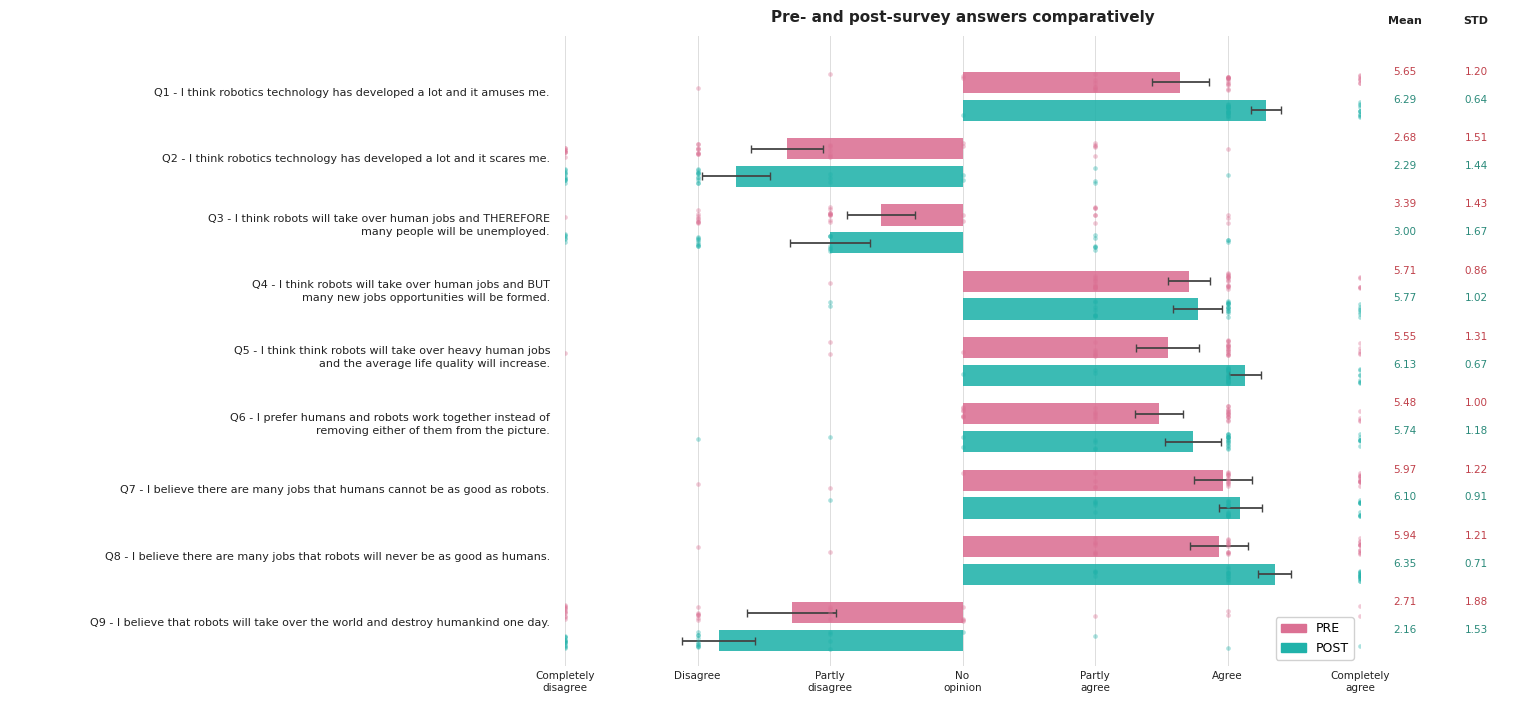

In [8]:
# =============================================================================
# PRE / POST SURVEY — Horizontal bar chart  (1–7 Likert scale)
# Assumes pre_q, post_q, shift, Q_LABELS, Q_DIRECTION are already defined.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker

# ── Full question text (same order as Q_LABELS) ───────────────────────────────
FULL_LABELS = [
    "Q1 - I think robotics technology has developed a lot and it amuses me.",
    "Q2 - I think robotics technology has developed a lot and it scares me.",
    "Q3 - I think robots will take over human jobs and THEREFORE\nmany people will be unemployed.",
    "Q4 - I think robots will take over human jobs and BUT\nmany new jobs opportunities will be formed.",
    "Q5 - I think think robots will take over heavy human jobs\nand the average life quality will increase.",
    "Q6 - I prefer humans and robots work together instead of\nremoving either of them from the picture.",
    "Q7 - I believe there are many jobs that humans cannot be as good as robots.",
    "Q8 - I believe there are many jobs that robots will never be as good as humans.",
    "Q9 - I believe that robots will take over the world and destroy humankind one day.",
]

# ── Likert x-axis tick positions and labels ───────────────────────────────────
LIKERT_TICKS  = [1, 2, 3, 4, 5, 6, 7]
LIKERT_LABELS = [
    "Completely\ndisagree",
    "Disagree",
    "Partly\ndisagree",
    "No\nopinion",
    "Partly\nagree",
    "Agree",
    "Completely\nagree",
]

# ── Colors ────────────────────────────────────────────────────────────────────
PRE_COLOR  = "palevioletred"
POST_COLOR = "lightseagreen"
PRE_DARK   = '#c0404a'
POST_DARK  = '#2a8a7a'
GRID_COLOR = '#dddddd'
TEXT_COLOR = '#222222'

# ── Layout constants ──────────────────────────────────────────────────────────
BAR_H  = 0.32    # height of each bar
GAP    = 0.10    # gap between PRE and POST bars within a question
N_Q    = len(Q_LABELS)

# ── Compute means, SEM, STD ───────────────────────────────────────────────────
pre_mean  = pre_q[Q_LABELS].mean()
post_mean = post_q[Q_LABELS].mean()
pre_sem   = pre_q[Q_LABELS].sem()
post_sem  = post_q[Q_LABELS].sem()
pre_std   = pre_q[Q_LABELS].std()
post_std  = post_q[Q_LABELS].std()

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 7.5), facecolor='white')

# Three axes: question labels | bars | mean+std table
ax_lbl  = fig.add_axes([0.00, 0.10, 0.36, 0.84])   # question text
ax_bars = fig.add_axes([0.37, 0.10, 0.53, 0.84])   # bar chart
ax_tbl  = fig.add_axes([0.91, 0.10, 0.09, 0.84])   # mean / std columns

for a in [ax_lbl, ax_tbl]:
    a.axis('off')

ax_bars.set_facecolor('white')
for spine in ax_bars.spines.values():
    spine.set_visible(False)

# ── Draw bars ─────────────────────────────────────────────────────────────────
rng = np.random.default_rng(42)

for i, q in enumerate(Q_LABELS):
    # Q1 at top → invert index
    yi     = (N_Q - 1 - i)
    y_pre  = yi + GAP / 2
    y_post = yi - BAR_H - GAP / 2

    m_pre, m_post = pre_mean[q],  post_mean[q]
    s_pre, s_post = pre_sem[q],   post_sem[q]

    # Bars
    ax_bars.barh(y_pre,  m_pre  - 4, height=BAR_H,
             color=PRE_COLOR,  alpha=0.88, zorder=3, left=4)
    ax_bars.barh(y_post, m_post - 4, height=BAR_H,
                color=POST_COLOR, alpha=0.88, zorder=3, left=4)

    # SEM error bars
    ax_bars.errorbar(m_pre,  y_pre,  xerr=s_pre,  fmt='none',
                     color='#444', lw=1.3, capsize=3, zorder=4)
    ax_bars.errorbar(m_post, y_post, xerr=s_post, fmt='none',
                     color='#444', lw=1.3, capsize=3, zorder=4)

    # Individual data points (jittered)
    pre_vals  = pre_q[q].values
    post_vals = post_q[q].values
    j_pre  = rng.uniform(-BAR_H * 0.40, BAR_H * 0.40, len(pre_vals))
    j_post = rng.uniform(-BAR_H * 0.40, BAR_H * 0.40, len(post_vals))
    ax_bars.scatter(pre_vals,  y_pre  + j_pre,
                    color=PRE_COLOR,  s=11, alpha=0.38, zorder=5, linewidths=0)
    ax_bars.scatter(post_vals, y_post + j_post,
                    color=POST_COLOR, s=11, alpha=0.38, zorder=5, linewidths=0)

# ── Bar chart axes ────────────────────────────────────────────────────────────
ax_bars.set_xlim(0.5, 7.5)
ax_bars.set_ylim(-0.75, N_Q - 0.25)
ax_bars.set_yticks([])

# Vertical grid lines at each Likert point
for x in LIKERT_TICKS:
    ax_bars.axvline(x, color=GRID_COLOR, lw=0.7, zorder=1)

# x-axis ticks and labels
ax_bars.set_xticks(LIKERT_TICKS)
ax_bars.set_xticklabels(LIKERT_LABELS, fontsize=7.5, color=TEXT_COLOR)
ax_bars.tick_params(axis='x', length=0, pad=4)
ax_bars.tick_params(axis='y', length=0)

# Title
ax_bars.set_title(
    "Pre- and post-survey answers comparatively",
    fontsize=11, fontweight='bold', color=TEXT_COLOR, pad=10
)

# ── Question labels (left panel) ──────────────────────────────────────────────
ax_bars.set_xlim(1, 7)
ax_lbl.set_ylim(-0.75, N_Q - 0.25)

for i, label in enumerate(FULL_LABELS):
    yi       = (N_Q - 1 - i)
    y_center = yi - (BAR_H / 2 + GAP / 2) / 2
    ax_lbl.text(
        1.0, y_center, label,
        ha='right', va='center', fontsize=8, color=TEXT_COLOR,
        linespacing=1.35,
    )

# ── Mean + STD table (right panel) ───────────────────────────────────────────
ax_tbl.set_xlim(0, 1)
ax_tbl.set_ylim(-0.75, N_Q - 0.25)

# Column headers
ax_tbl.text(0.22, N_Q - 0.10, "Mean", ha='center', va='bottom',
            fontsize=8, fontweight='bold', color=TEXT_COLOR)
ax_tbl.text(0.75, N_Q - 0.10, "STD",  ha='center', va='bottom',
            fontsize=8, fontweight='bold', color=TEXT_COLOR)

for i, q in enumerate(Q_LABELS):
    yi     = (N_Q - 1 - i)
    y_pre  = yi + GAP / 2 + BAR_H / 2        # vertical center of PRE bar
    y_post = yi - GAP / 2 - BAR_H / 2        # vertical center of POST bar

    ax_tbl.text(0.22, y_pre,  f"{pre_mean[q]:.2f}",  ha='center', va='center',
                fontsize=7.5, color=PRE_DARK)
    ax_tbl.text(0.22, y_post, f"{post_mean[q]:.2f}", ha='center', va='center',
                fontsize=7.5, color=POST_DARK)
    ax_tbl.text(0.75, y_pre,  f"{pre_std[q]:.2f}",   ha='center', va='center',
                fontsize=7.5, color=PRE_DARK)
    ax_tbl.text(0.75, y_post, f"{post_std[q]:.2f}",  ha='center', va='center',
                fontsize=7.5, color=POST_DARK)

# ── Legend ────────────────────────────────────────────────────────────────────
pre_patch  = mpatches.Patch(color=PRE_COLOR,  label='PRE')
post_patch = mpatches.Patch(color=POST_COLOR, label='POST')
ax_bars.legend(
    handles=[pre_patch, post_patch],
    loc='lower right', fontsize=9,
    framealpha=0.9, edgecolor='#cccccc',
)

plt.savefig('pre_post_survey_likert.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

### SHAPIRO-WILK NORMALITY TESTS
This is only to justify why we use Wilcoxon tes 
Answer of:  "are the shift distributions normal?"

since 8/9 are not, it confirms Wilcoxon is the right choice for Step 3.

In [9]:
print()
print("=" * 58)
print("SHAPIRO-WILK NORMALITY TEST ON SHIFT SCORES")
print("p < .05  →  non-normal  →  Wilcoxon is the correct test")
print("=" * 58)
print(f"\n{'Question':<24} {'W':>8}  {'p':>8}  {'Normal?':>9}")
print("-" * 58)
 
for q in Q_LABELS:
    W, p    = stats.shapiro(shift[q])
    verdict = "YES" if p >= 0.05 else "NO  ✗"
    print(f"  {q:<22} {W:>8.4f}  {p:>8.4f}  {verdict:>9}")
 
print()
print("→ Wilcoxon signed-rank test is appropriate for Step 3.")
print("→ No composite score computed — questions analysed independently.")


SHAPIRO-WILK NORMALITY TEST ON SHIFT SCORES
p < .05  →  non-normal  →  Wilcoxon is the correct test

Question                        W         p    Normal?
----------------------------------------------------------
  Q1 Amuses me             0.8816    0.0026      NO  ✗
  Q2 Scares me             0.7110    0.0000      NO  ✗
  Q3 Unemployment          0.9004    0.0074      NO  ✗
  Q4 New jobs              0.8350    0.0002      NO  ✗
  Q5 Life quality          0.7891    0.0000      NO  ✗
  Q6 HRC preference        0.9397    0.0807        YES
  Q7 Humans better         0.8765    0.0020      NO  ✗
  Q8 Robots better         0.8963    0.0059      NO  ✗
  Q9 Destroy humankind     0.6800    0.0000      NO  ✗

→ Wilcoxon signed-rank test is appropriate for Step 3.
→ No composite score computed — questions analysed independently.


# Wilcoxon signed-rank test

#### HELPER — Benjamini-Hochberg FDR correction

In [10]:
def bh_correction(p_values, alpha=0.05):
    """
    Benjamini-Hochberg FDR correction.
    Returns array of adjusted p-values and boolean reject array.
    """
    p   = np.array(p_values)
    n   = len(p)
    # rank from smallest to largest
    order      = np.argsort(p)
    rank       = np.empty_like(order)
    rank[order] = np.arange(1, n + 1)
    # adjusted p = p * n / rank, capped at 1, monotone from right
    p_adj = np.minimum(1, p * n / rank)
    # enforce monotonicity from right to left
    for i in range(n - 2, -1, -1):
        p_adj[order[i]] = min(p_adj[order[i]], p_adj[order[i + 1]])
    reject = p_adj <= alpha
    return p_adj, reject

In [11]:
print("=" * 72)
print("STEP 3 — PAIRED WILCOXON SIGNED-RANK TESTS  (n=31, two-sided)")
print("=" * 72)
 
records = []
 
for q in Q_LABELS:
    pre_vals  = pre_q[q].values
    post_vals = post_q[q].values
    s         = shift[q].values
 
    # --- Wilcoxon test ---
    # zero_method='wilcox' drops zero-difference pairs (standard approach)
    W, p_raw = stats.wilcoxon(pre_vals, post_vals,
                               zero_method='wilcox',
                               alternative='two-sided')
 
    # --- Effect size r = Z / sqrt(N) ---
    # We derive Z from the two-tailed p-value
    # norm.ppf(p/2) gives the negative tail; abs() for magnitude
    z = abs(norm.ppf(p_raw / 2))
    r = z / np.sqrt(len(pre_vals))
 
    # --- Effect size label (Cohen 1992) ---
    if   r >= 0.50: r_label = "large"
    elif r >= 0.30: r_label = "medium"
    elif r >= 0.10: r_label = "small"
    else:           r_label = "negligible"
 
    direction = Q_DIRECTION[q]
    # Was the shift in the expected (positive-for-HRC) direction?
    mean_delta = s.mean()
    if direction == "good":
        expected = "YES ✓" if mean_delta > 0 else "NO  ✗"
    elif direction == "bad":
        expected = "YES ✓" if mean_delta < 0 else "NO  ✗"
    else:
        expected = "n/a"
 
    records.append({
        'question':    q,
        'direction':   direction,
        'mean_delta':  mean_delta,
        'W':           W,
        'p_raw':       p_raw,
        'z':           z,
        'r':           r,
        'r_label':     r_label,
        'expected_dir': expected,
    })
 
results = pd.DataFrame(records)
 
# --- Apply BH correction ---
p_adj, reject = bh_correction(results['p_raw'].values, alpha=0.05)
results['p_adj']   = p_adj
results['sig_bh']  = reject
 
# --- Raw significance stars (for reference, pre-correction) ---
def stars(p):
    if   p < 0.001: return '***'
    elif p < 0.01:  return '**'
    elif p < 0.05:  return '*'
    elif p < 0.10:  return '~'
    else:           return ''
 
results['stars_raw'] = results['p_raw'].apply(stars)
results['stars_adj'] = results['p_adj'].apply(stars)

STEP 3 — PAIRED WILCOXON SIGNED-RANK TESTS  (n=31, two-sided)


In [12]:
results

,question,direction,mean_delta,W,p_raw,z,r,r_label,expected_dir,p_adj,sig_bh,stars_raw,stars_adj
0,Q1 Amuses me,good,0.645161,39.0,0.010162,2.570264,0.461633,medium,YES ✓,0.047187,True,*,*
1,Q2 Scares me,bad,-0.387097,11.0,0.018736,2.350743,0.422206,medium,YES ✓,0.056208,False,*,~
2,Q3 Unemployment,bad,-0.387097,35.0,0.079708,1.752384,0.314737,medium,YES ✓,0.119562,False,~,
3,Q4 New jobs,good,0.064516,48.5,0.792794,0.262684,0.047179,negligible,YES ✓,0.891894,False,,
4,Q5 Life quality,good,0.580645,16.5,0.010486,2.559377,0.459678,medium,YES ✓,0.047187,True,*,*
5,Q6 HRC preference,good,0.258065,66.0,0.228177,1.205069,0.216437,small,YES ✓,0.293370,False,,
6,Q7 Humans better,neutral,0.129032,84.5,0.964298,0.044761,0.008039,negligible,n/a,0.964298,False,,
7,Q8 Robots better,neutral,0.419355,38.0,0.059153,1.887051,0.338924,medium,n/a,0.106476,False,~,
8,Q9 Destroy humankind,bad,-0.548387,6.5,0.057145,1.902203,0.341646,medium,YES ✓,0.106476,False,~,


Printing results:

In [13]:
print(f"\n{'Question':<24} {'Dir':>5}  {'Δμ':>6}  {'W':>7}  "
      f"{'p_raw':>7}  {'p_adj(BH)':>10}  {'r':>5}  {'size':>10}  "
      f"{'raw':>4}  {'BH':>4}  {'Correct dir?':>13}")
print("-" * 105)
 
for _, row in results.iterrows():
    dir_tag = "↑✓" if row['direction'] == "good" else \
              "↑✗" if row['direction'] == "bad"  else "↑~"
    print(f"  {row['question']:<22} {dir_tag:>5}  {row['mean_delta']:>+6.3f}  "
          f"{row['W']:>7.1f}  {row['p_raw']:>7.4f}  {row['p_adj']:>10.4f}  "
          f"{row['r']:>5.3f}  {row['r_label']:>10}  "
          f"{row['stars_raw']:>4}  {row['stars_adj']:>4}  {row['expected_dir']:>13}")
 
print("-" * 105)
print(f"\nSignificant after BH correction (p_adj ≤ .05):  "
      f"{results['sig_bh'].sum()} / {len(results)} questions")
print(f"Shifted in expected direction:  "
      f"{(results['expected_dir']=='YES ✓').sum()} / {len(results)} questions")
 
print("""
Columns:
  Dir       — ↑✓ positive shift = good | ↑✗ positive shift = bad | ↑~ neutral
  Δμ        — mean POST−PRE shift (1–7 scale)
  W         — Wilcoxon test statistic
  p_raw     — uncorrected two-sided p-value
  p_adj(BH) — Benjamini-Hochberg adjusted p-value
  r         — effect size r = Z/√N  (small≥.1, medium≥.3, large≥.5)
  raw / BH  — significance stars before / after correction
  Correct dir? — did the shift go in the expected direction?
 
Note: zero_method='wilcox' — zero-difference pairs excluded from ranking.
""")


Question                   Dir      Δμ        W    p_raw   p_adj(BH)      r        size   raw    BH   Correct dir?
---------------------------------------------------------------------------------------------------------
  Q1 Amuses me              ↑✓  +0.645     39.0   0.0102      0.0472  0.462      medium     *     *          YES ✓
  Q2 Scares me              ↑✗  -0.387     11.0   0.0187      0.0562  0.422      medium     *     ~          YES ✓
  Q3 Unemployment           ↑✗  -0.387     35.0   0.0797      0.1196  0.315      medium     ~                YES ✓
  Q4 New jobs               ↑✓  +0.065     48.5   0.7928      0.8919  0.047  negligible                      YES ✓
  Q5 Life quality           ↑✓  +0.581     16.5   0.0105      0.0472  0.460      medium     *     *          YES ✓
  Q6 HRC preference         ↑✓  +0.258     66.0   0.2282      0.2934  0.216       small                      YES ✓
  Q7 Humans better          ↑~  +0.129     84.5   0.9643      0.9643  0.008  negligible 

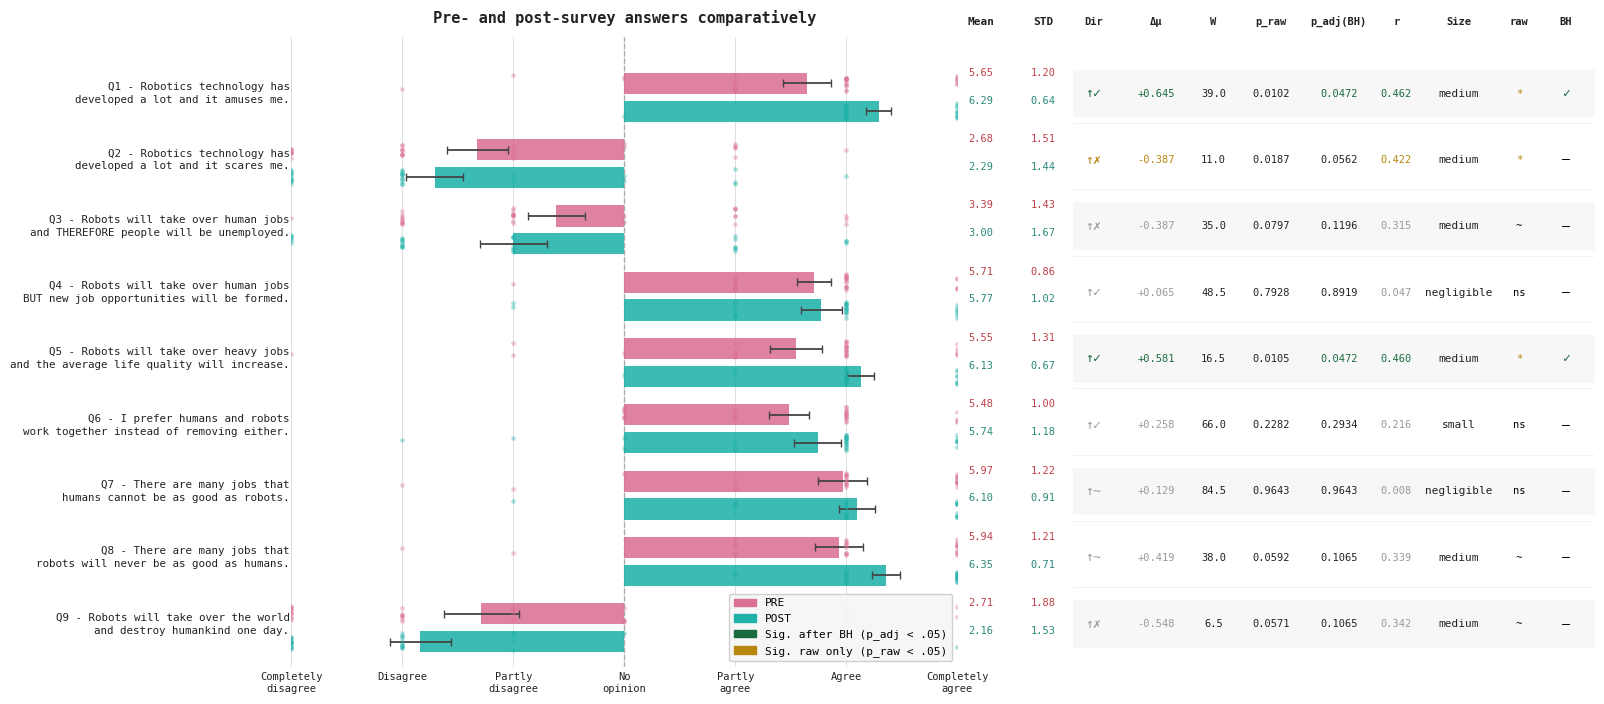

: 

In [ ]:
# =============================================================================
# PRE / POST SURVEY — Horizontal bar chart (1–7 Likert scale)
#                   + Wilcoxon results table
# Assumes pre_q, post_q, shift, Q_LABELS, Q_DIRECTION, results are defined.
# 'results' is the DataFrame from the Wilcoxon cell (Cell 16/17 in notebook).
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

# ── Full question text (same order as Q_LABELS) ───────────────────────────────
FULL_LABELS = [
    "Q1 - Robotics technology has\ndeveloped a lot and it amuses me.",
    "Q2 - Robotics technology has\ndeveloped a lot and it scares me.",
    "Q3 - Robots will take over human jobs\nand THEREFORE people will be unemployed.",
    "Q4 - Robots will take over human jobs\nBUT new job opportunities will be formed.",
    "Q5 - Robots will take over heavy jobs\nand the average life quality will increase.",
    "Q6 - I prefer humans and robots\nwork together instead of removing either.",
    "Q7 - There are many jobs that\nhumans cannot be as good as robots.",
    "Q8 - There are many jobs that\nrobots will never be as good as humans.",
    "Q9 - Robots will take over the world\nand destroy humankind one day.",
]

# ── Likert x-axis ─────────────────────────────────────────────────────────────
LIKERT_TICKS  = [1, 2, 3, 4, 5, 6, 7]
LIKERT_LABELS = [
    "Completely\ndisagree", "Disagree", "Partly\ndisagree",
    "No\nopinion", "Partly\nagree", "Agree", "Completely\nagree",
]

# ── Colors ────────────────────────────────────────────────────────────────────
PRE_COLOR  = "palevioletred"
POST_COLOR = "lightseagreen"
PRE_DARK   = '#c0404a'
POST_DARK  = '#2a8a7a'
GRID_COLOR = '#dddddd'
TEXT_COLOR = '#222222'
SIG_BH_COLOR   = '#1a6b3c'   # dark green — survives BH
SIG_RAW_COLOR  = '#b8860b'   # dark gold  — raw only
INSIG_COLOR    = '#999999'   # grey       — not significant

# ── Direction symbols ─────────────────────────────────────────────────────────
DIR_SYMBOL = {
    'good':    '↑✓',
    'bad':     '↑✗',
    'neutral': '↑~',
}

# ── Layout constants ──────────────────────────────────────────────────────────
BAR_H = 0.32
GAP   = 0.10
N_Q   = len(Q_LABELS)

# ── Compute stats ─────────────────────────────────────────────────────────────
pre_mean  = pre_q[Q_LABELS].mean()
post_mean = post_q[Q_LABELS].mean()
pre_sem   = pre_q[Q_LABELS].sem()
post_sem  = post_q[Q_LABELS].sem()
pre_std   = pre_q[Q_LABELS].std()
post_std  = post_q[Q_LABELS].std()

# ── Figure layout ─────────────────────────────────────────────────────────────
# Panels (left → right):
#   ax_lbl   : question text
#   ax_bars  : bar chart
#   ax_tbl   : mean / std
#   ax_stats : Wilcoxon columns
fig = plt.figure(figsize=(18, 7.5), facecolor='white')

ax_lbl   = fig.add_axes([0.00,  0.10, 0.150, 0.84])   # question labels
ax_bars  = fig.add_axes([0.151, 0.10, 0.370, 0.84])   # bar chart
ax_tbl   = fig.add_axes([0.520, 0.10, 0.065, 0.84])   # mean / std
ax_stats = fig.add_axes([0.585, 0.10, 0.290, 0.84])   # Wilcoxon table

for a in [ax_lbl, ax_tbl, ax_stats]:
    a.axis('off')

ax_bars.set_facecolor('white')
for spine in ax_bars.spines.values():
    spine.set_visible(False)

# ── Draw bars ─────────────────────────────────────────────────────────────────
rng = np.random.default_rng(42)

for i, q in enumerate(Q_LABELS):
    yi     = (N_Q - 1 - i)
    y_pre  = yi + GAP / 2
    y_post = yi - BAR_H - GAP / 2

    m_pre, m_post = pre_mean[q], post_mean[q]
    s_pre, s_post = pre_sem[q],  post_sem[q]

    ax_bars.barh(y_pre,  m_pre  - 4, height=BAR_H,
                 color=PRE_COLOR,  alpha=0.88, zorder=3, left=4)
    ax_bars.barh(y_post, m_post - 4, height=BAR_H,
                 color=POST_COLOR, alpha=0.88, zorder=3, left=4)

    ax_bars.errorbar(m_pre,  y_pre,  xerr=s_pre,  fmt='none',
                     color='#444', lw=1.3, capsize=3, zorder=4)
    ax_bars.errorbar(m_post, y_post, xerr=s_post, fmt='none',
                     color='#444', lw=1.3, capsize=3, zorder=4)

    pre_vals  = pre_q[q].values
    post_vals = post_q[q].values
    j_pre  = rng.uniform(-BAR_H * 0.40, BAR_H * 0.40, len(pre_vals))
    j_post = rng.uniform(-BAR_H * 0.40, BAR_H * 0.40, len(post_vals))
    ax_bars.scatter(pre_vals,  y_pre  + j_pre,
                    color=PRE_COLOR,  s=11, alpha=0.38, zorder=5, linewidths=0)
    ax_bars.scatter(post_vals, y_post + j_post,
                    color=POST_COLOR, s=11, alpha=0.38, zorder=5, linewidths=0)

# ── Bar chart axes ────────────────────────────────────────────────────────────
ax_bars.set_xlim(1, 7)
ax_bars.set_ylim(-0.75, N_Q - 0.25)
ax_bars.set_yticks([])

for x in LIKERT_TICKS:
    ax_bars.axvline(x, color=GRID_COLOR, lw=0.7, zorder=1)

# "No opinion" center line
ax_bars.axvline(4, color='#aaaaaa', lw=1.0, ls='--', zorder=2)

ax_bars.set_xticks(LIKERT_TICKS)
ax_bars.set_xticklabels(LIKERT_LABELS, fontsize=7.5, color=TEXT_COLOR)
ax_bars.tick_params(axis='x', length=0, pad=4)
ax_bars.tick_params(axis='y', length=0)
ax_bars.set_title(
    "Pre- and post-survey answers comparatively",
    fontsize=11, fontweight='bold', color=TEXT_COLOR, pad=10
)

# ── Question labels ───────────────────────────────────────────────────────────
ax_lbl.set_xlim(0, 1)
ax_lbl.set_ylim(-0.75, N_Q - 0.25)

for i, label in enumerate(FULL_LABELS):
    yi       = (N_Q - 1 - i)
    y_center = yi - (BAR_H / 2 + GAP / 2) / 2
    ax_lbl.text(1.0, y_center, label,
                ha='right', va='center', fontsize=7.8, color=TEXT_COLOR,
                linespacing=1.35)

# ── Mean + STD panel ──────────────────────────────────────────────────────────
ax_tbl.set_xlim(0, 1)
ax_tbl.set_ylim(-0.75, N_Q - 0.25)

ax_tbl.text(0.22, N_Q - 0.10, "Mean", ha='center', va='bottom',
            fontsize=8, fontweight='bold', color=TEXT_COLOR)
ax_tbl.text(0.75, N_Q - 0.10, "STD",  ha='center', va='bottom',
            fontsize=8, fontweight='bold', color=TEXT_COLOR)

for i, q in enumerate(Q_LABELS):
    yi     = (N_Q - 1 - i)
    y_pre  = yi + GAP / 2 + BAR_H / 2
    y_post = yi - GAP / 2 - BAR_H / 2

    ax_tbl.text(0.22, y_pre,  f"{pre_mean[q]:.2f}",  ha='center', va='center',
                fontsize=7.5, color=PRE_DARK)
    ax_tbl.text(0.22, y_post, f"{post_mean[q]:.2f}", ha='center', va='center',
                fontsize=7.5, color=POST_DARK)
    ax_tbl.text(0.75, y_pre,  f"{pre_std[q]:.2f}",   ha='center', va='center',
                fontsize=7.5, color=PRE_DARK)
    ax_tbl.text(0.75, y_post, f"{post_std[q]:.2f}",  ha='center', va='center',
                fontsize=7.5, color=POST_DARK)

# ── Wilcoxon stats panel ──────────────────────────────────────────────────────
ax_stats.set_xlim(0, 1)
ax_stats.set_ylim(-0.75, N_Q - 0.25)

# Column x-positions and headers
COL_X = {
    'dir':      0.04,
    'delta':    0.16,
    'W':        0.27,
    'p_raw':    0.38,
    'p_adj':    0.51,
    'r':        0.62,
    'size':     0.74,
    'sig_raw':  0.855,
    'sig_bh':   0.945,
}

HEADERS = {
    'dir':     'Dir',
    'delta':   'Δμ',
    'W':       'W',
    'p_raw':   'p_raw',
    'p_adj':   'p_adj(BH)',
    'r':       'r',
    'size':    'Size',
    'sig_raw': 'raw',
    'sig_bh':  'BH',
}

# Draw header row
for col, x in COL_X.items():
    ax_stats.text(x, N_Q - 0.10, HEADERS[col],
                  ha='center', va='bottom', fontsize=7.5,
                  fontweight='bold', color=TEXT_COLOR)

# Thin header separator line
ax_stats.axhline(N_Q - 0.22, color='#cccccc', lw=0.8,
                 xmin=0.0, xmax=1.0)

# Draw rows
for i, q in enumerate(Q_LABELS):
    yi       = (N_Q - 1 - i)
    y_center = yi - (BAR_H / 2 + GAP / 2) / 2

    row = results[results['question'] == q].iloc[0]

    # Significance color logic
    if row['sig_bh']:
        row_color = SIG_BH_COLOR
    elif row['p_raw'] < 0.05:
        row_color = SIG_RAW_COLOR
    else:
        row_color = INSIG_COLOR

    # Subtle alternating row background
    if i % 2 == 0:
        ax_stats.add_patch(FancyBboxPatch(
            (0.0, y_center - 0.36), 1.0, 0.72,
            boxstyle="square,pad=0", linewidth=0,
            facecolor='#f7f7f7', zorder=0
        ))

    # Direction symbol
    direction = Q_DIRECTION[q]
    dir_sym   = DIR_SYMBOL[direction]
    ax_stats.text(COL_X['dir'], y_center, dir_sym,
                  ha='center', va='center', fontsize=9.5, color=row_color)

    # Δμ  (show sign explicitly)
    delta = row['mean_delta']
    ax_stats.text(COL_X['delta'], y_center, f"{delta:+.3f}",
                  ha='center', va='center', fontsize=7.5, color=row_color)

    # W statistic
    ax_stats.text(COL_X['W'], y_center, f"{row['W']:.1f}",
                  ha='center', va='center', fontsize=7.5, color=TEXT_COLOR)

    # p_raw
    ax_stats.text(COL_X['p_raw'], y_center, f"{row['p_raw']:.4f}",
                  ha='center', va='center', fontsize=7.5, color=TEXT_COLOR)

    # p_adj(BH)
    p_adj_col = SIG_BH_COLOR if row['sig_bh'] else TEXT_COLOR
    ax_stats.text(COL_X['p_adj'], y_center, f"{row['p_adj']:.4f}",
                  ha='center', va='center', fontsize=7.5, color=p_adj_col)

    # r effect size
    ax_stats.text(COL_X['r'], y_center, f"{row['r']:.3f}",
                  ha='center', va='center', fontsize=7.5, color=row_color)

    # Effect size label
    ax_stats.text(COL_X['size'], y_center, row['r_label'],
                  ha='center', va='center', fontsize=8, color=TEXT_COLOR)

    # Raw significance stars
    raw_stars = row['stars_raw'] if row['stars_raw'] else 'ns'
    ax_stats.text(COL_X['sig_raw'], y_center, raw_stars,
                  ha='center', va='center', fontsize=7.5,
                  color=SIG_RAW_COLOR if row['p_raw'] < 0.05 else TEXT)

    # BH significance
    bh_label = '✓' if row['sig_bh'] else '—'
    ax_stats.text(COL_X['sig_bh'], y_center, bh_label,
                  ha='center', va='center', fontsize=9.5,
                  color=SIG_BH_COLOR if row['sig_bh'] else TEXT)

# Thin horizontal row separators
for i in range(N_Q - 1):
    yi = (N_Q - 1 - i) - BAR_H - GAP / 2 - 0.18
    ax_stats.axhline(yi, color='#eeeeee', lw=0.5, xmin=0.0, xmax=1.0)

# ── Legend ────────────────────────────────────────────────────────────────────
pre_patch  = mpatches.Patch(color=PRE_COLOR,  label='PRE')
post_patch = mpatches.Patch(color=POST_COLOR, label='POST')
bh_patch   = mpatches.Patch(color=SIG_BH_COLOR,  label='Sig. after BH (p_adj < .05)')
raw_patch  = mpatches.Patch(color=SIG_RAW_COLOR, label='Sig. raw only (p_raw < .05)')
ax_bars.legend(
    handles=[pre_patch, post_patch, bh_patch, raw_patch],
    loc='lower right', fontsize=8,
    framealpha=0.9, edgecolor='#cccccc',
)

plt.savefig('pre_post_wilcoxon_combined.png', dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()

PLOT — Forest-style effect size chart with significance

✓ Plot saved → step3_wilcoxon_results.png
✓ Step 3 complete — ready for Step 4 (parameter correlations).


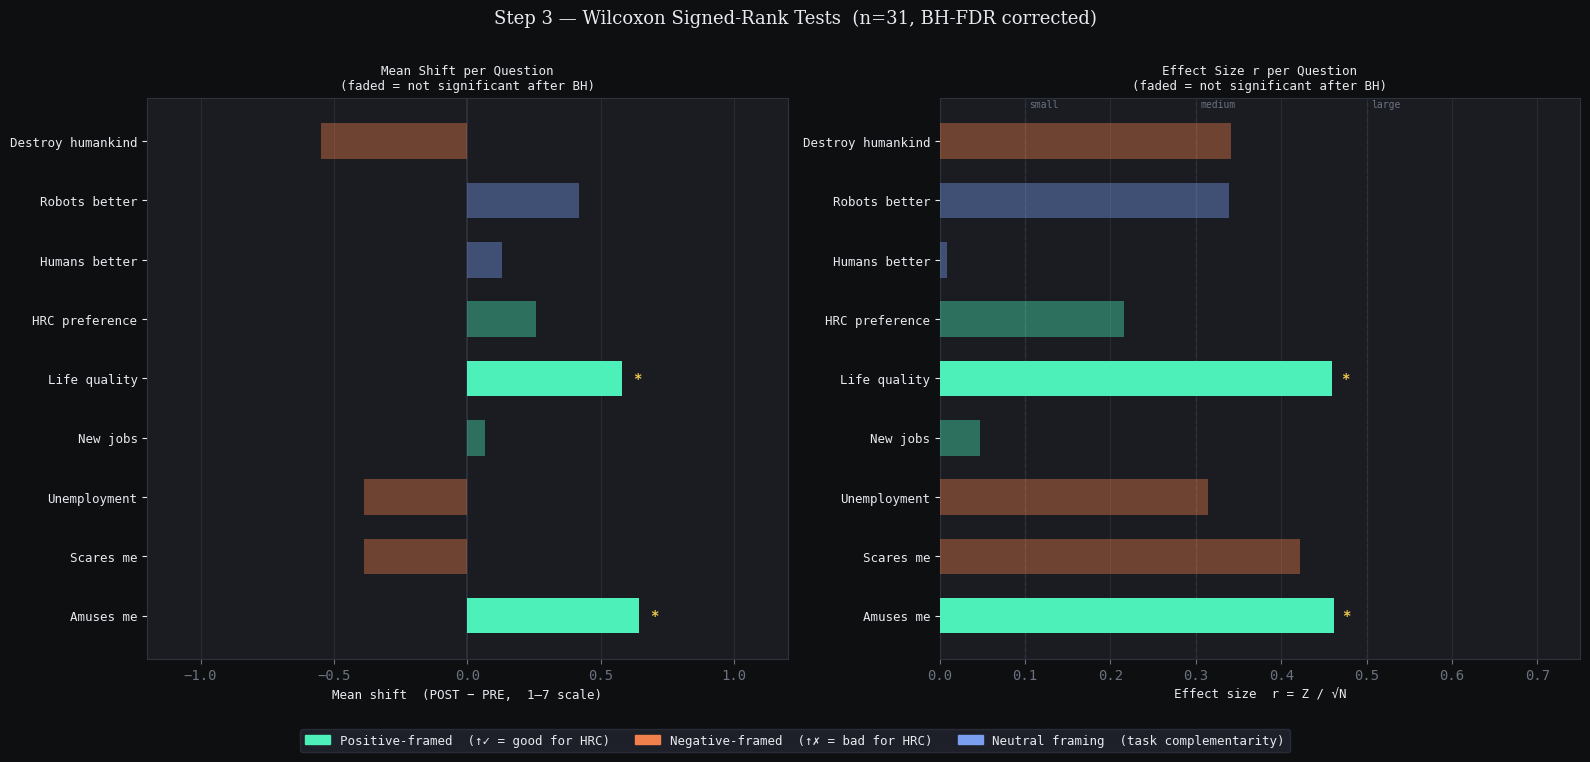

In [15]:
DARK   = '#0e0f11'
SURF   = '#1a1c22'
SURF2  = '#22252e'
BORDER = '#2e323d'
GREEN  = '#4cf0b8'
RED    = '#f0804c'
YELLOW = '#f0c84c'
BLUE   = '#7a9ef0'
MUTED  = '#6b7280'
TEXT   = '#e8eaf0'
 
plt.rcParams.update({
    'figure.facecolor': DARK,   'axes.facecolor': SURF,
    'axes.edgecolor':   BORDER, 'axes.labelcolor': TEXT,
    'xtick.color':      MUTED,  'ytick.color': TEXT,
    'text.color':       TEXT,   'grid.color': BORDER,
    'grid.linewidth':   0.5,    'font.family': 'monospace',
})
 
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor=DARK)
fig.suptitle(
    "Step 3 — Wilcoxon Signed-Rank Tests  (n=31, BH-FDR corrected)",
    fontsize=13, color=TEXT, y=1.01, fontfamily='serif'
)
 
y_pos     = np.arange(len(Q_LABELS))
q_short   = [q.split(' ', 1)[1] for q in Q_LABELS]   # strip "Q1 " etc.
 
# ── LEFT: Mean shift with significance markers ───────────────────────────────
ax1 = axes[0]
for i, (_, row) in enumerate(results.iterrows()):
    color = GREEN if row['direction'] == 'good' else \
            RED   if row['direction'] == 'bad'  else BLUE
    alpha = 1.0 if row['sig_bh'] else 0.4
    ax1.barh(i, row['mean_delta'], color=color, alpha=alpha,
             height=0.6, zorder=3)
    # BH-significant marker
    if row['sig_bh']:
        ax1.text(row['mean_delta'] + (0.04 if row['mean_delta'] >= 0 else -0.04),
                 i, row['stars_adj'],
                 va='center', ha='left' if row['mean_delta'] >= 0 else 'right',
                 fontsize=10, color=YELLOW, fontweight='bold')
 
ax1.axvline(0, color=BORDER, lw=1.2, zorder=2)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(q_short, fontsize=9)
ax1.set_xlabel("Mean shift  (POST − PRE,  1–7 scale)", fontsize=9)
ax1.set_title("Mean Shift per Question\n(faded = not significant after BH)",
              fontsize=9, color=TEXT)
ax1.grid(axis='x', zorder=0)
ax1.set_xlim(-1.2, 1.2)
 
# ── RIGHT: Effect size r ─────────────────────────────────────────────────────
ax2 = axes[1]
for i, (_, row) in enumerate(results.iterrows()):
    color = GREEN if row['direction'] == 'good' else \
            RED   if row['direction'] == 'bad'  else BLUE
    alpha = 1.0 if row['sig_bh'] else 0.4
    ax2.barh(i, row['r'], color=color, alpha=alpha, height=0.6, zorder=3)
    if row['sig_bh']:
        ax2.text(row['r'] + 0.01, i, row['stars_adj'],
                 va='center', ha='left',
                 fontsize=10, color=YELLOW, fontweight='bold')
 
# Reference lines for effect size thresholds
for x, lbl in [(0.10, 'small'), (0.30, 'medium'), (0.50, 'large')]:
    ax2.axvline(x, color=BORDER, lw=1, ls='--', zorder=1)
    ax2.text(x + 0.005, len(Q_LABELS) - 0.3, lbl,
             fontsize=7, color=MUTED, va='top')
 
ax2.set_yticks(y_pos)
ax2.set_yticklabels(q_short, fontsize=9)
ax2.set_xlabel("Effect size  r = Z / √N", fontsize=9)
ax2.set_title("Effect Size r per Question\n(faded = not significant after BH)",
              fontsize=9, color=TEXT)
ax2.grid(axis='x', zorder=0)
ax2.set_xlim(0, 0.75)
 
# Shared legend
fig.legend(
    handles=[
        mpatches.Patch(color=GREEN,  label='Positive-framed  (↑✓ = good for HRC)'),
        mpatches.Patch(color=RED,    label='Negative-framed  (↑✗ = bad for HRC)'),
        mpatches.Patch(color=BLUE,   label='Neutral framing  (task complementarity)'),
    ],
    loc='lower center', ncol=3,
    facecolor=SURF2, edgecolor=BORDER, fontsize=9,
    bbox_to_anchor=(0.5, -0.06)
)
 
plt.tight_layout()
OUT = 'step3_wilcoxon_results.png'
plt.savefig(OUT, dpi=150, bbox_inches='tight')
 
print(f"✓ Plot saved → {OUT}")
print("✓ Step 3 complete — ready for Step 4 (parameter correlations).")

# STEP 4 — User Parameter × Shift Correlations
For each of 9 user parameters × 9 shift scores:
  - Continuous params (age, gaming, programming):
      Spearman rho
  - Ordinal Likert params (robot_familiarity, proximity, industrial, interest):
      Spearman rho  AND  median-split Mann-Whitney U (both reported)
  - Binary (sex):
      Mann-Whitney U (Women vs Men)
  - BH-FDR correction applied separately to each test family
  - Heatmap + ranked significance list

In [16]:
CONTINUOUS_PARAMS = ['age', 'current_gaming', 'past_gaming', 'programming']
LIKERT_PARAMS     = ['robot_familiarity', 'robot_proximity',
                     'robot_industrial', 'robot_interest']
BINARY_PARAMS     = ['sex']

In [17]:
def stars(p):
    if   p < 0.001: return '***'
    elif p < 0.01:  return '**'
    elif p < 0.05:  return '*'
    elif p < 0.10:  return '~'
    return ''
 
def effect_label(r):
    r = abs(r)
    if   r >= 0.50: return 'large'
    elif r >= 0.30: return 'medium'
    elif r >= 0.10: return 'small'
    return 'negligible'

In [18]:
pre_raw.columns = ['exp_id'] + PARAM_COLS + Q_LABELS + ['nps1', 'nps2']
post_raw.rename(columns={post_raw.columns[0]: 'exp_id'}, inplace=True)
post_q_raw           = post_raw.iloc[:, 12:21].copy()
post_q_raw.columns   = Q_LABELS
post_q_raw['exp_id'] = post_raw['exp_id']
merged = pre_raw[['exp_id'] + PARAM_COLS + Q_LABELS].merge(
    post_q_raw, on='exp_id', suffixes=('_pre', '_post'))
assert len(merged) == 31

def encode_questions(df, labels, suffix):
    out = df[[f'{q}{suffix}' for q in labels]].replace(LIKERT_MAP).apply(
        pd.to_numeric, errors='coerce')
    out.columns = labels
    return out
 
pre_q  = encode_questions(merged, Q_LABELS, '_pre')
post_q = encode_questions(merged, Q_LABELS, '_post')
shift  = post_q - pre_q
 
# Encode parameters
params = merged[PARAM_COLS].copy()
for col in LIKERT_PARAMS:
    params[col] = params[col].replace(LIKERT_MAP).pipe(pd.to_numeric, errors='coerce')
for col in CONTINUOUS_PARAMS:
    params[col] = pd.to_numeric(params[col], errors='coerce')

### SPEARMAN (continuous + ordinal Likert params)

In [19]:
spearman_records = []
 
for param in CONTINUOUS_PARAMS + LIKERT_PARAMS:
    x = params[param].values
    for q in Q_LABELS:
        y        = shift[q].values
        rho, p   = stats.spearmanr(x, y)
        spearman_records.append({
            'param': param, 'question': q,
            'rho': rho, 'p_raw': p,
            'test': 'Spearman',
        })
 
sp_df          = pd.DataFrame(spearman_records)
p_adj, reject  = bh_correction(sp_df['p_raw'].values)
sp_df['p_adj'] = p_adj
sp_df['sig']   = reject
sp_df['stars_raw'] = sp_df['p_raw'].apply(stars)
sp_df['stars_adj'] = sp_df['p_adj'].apply(stars)
sp_df['effect']    = sp_df['rho'].apply(effect_label)

### MEDIAN SPLIT Mann-Whitney U  (Likert params only)

In [20]:
mw_likert_records = []
 
for param in LIKERT_PARAMS:
    x      = params[param].values
    median = np.median(x)
    lo_idx = x <= median
    hi_idx = x >  median
 
    for q in Q_LABELS:
        y     = shift[q].values
        lo, hi = y[lo_idx], y[hi_idx]
        if len(lo) < 3 or len(hi) < 3:
            continue
        U, p     = stats.mannwhitneyu(lo, hi, alternative='two-sided')
        # rank-biserial r
        n1, n2   = len(lo), len(hi)
        r_rb     = 1 - (2 * U) / (n1 * n2)
        mw_likert_records.append({
            'param': param, 'question': q,
            'rho': r_rb, 'p_raw': p,
            'U': U, 'n_lo': n1, 'n_hi': n2,
            'mean_lo': lo.mean(), 'mean_hi': hi.mean(),
            'test': 'Mann-Whitney (median split)',
        })
 
mw_df          = pd.DataFrame(mw_likert_records)
p_adj, reject  = bh_correction(mw_df['p_raw'].values)
mw_df['p_adj'] = p_adj
mw_df['sig']   = reject
mw_df['stars_raw'] = mw_df['p_raw'].apply(stars)
mw_df['stars_adj'] = mw_df['p_adj'].apply(stars)
mw_df['effect']    = mw_df['rho'].apply(effect_label)

### Mann-Whitney U  (sex: Women vs Men)

In [21]:
sex_records = []
women = params['sex'] == 'Woman'
men   = params['sex'] == 'Man'
 
for q in Q_LABELS:
    y         = shift[q].values
    yw, ym    = y[women], y[men]
    U, p      = stats.mannwhitneyu(yw, ym, alternative='two-sided')
    n1, n2    = len(yw), len(ym)
    r_rb      = 1 - (2 * U) / (n1 * n2)
    sex_records.append({
        'param': 'sex', 'question': q,
        'rho': r_rb, 'p_raw': p,
        'U': U, 'n_women': n1, 'n_men': n2,
        'mean_women': yw.mean(), 'mean_men': ym.mean(),
        'test': 'Mann-Whitney (sex)',
    })
 
sex_df         = pd.DataFrame(sex_records)
p_adj, reject  = bh_correction(sex_df['p_raw'].values)
sex_df['p_adj'] = p_adj
sex_df['sig']   = reject
sex_df['stars_raw'] = sex_df['p_raw'].apply(stars)
sex_df['stars_adj'] = sex_df['p_adj'].apply(stars)
sex_df['effect']    = sex_df['rho'].apply(effect_label)

Printing results:

In [22]:
print("=" * 80)
print("STEP 4 — PARAMETER × SHIFT CORRELATIONS  (BH-FDR corrected, n=31)")
print("=" * 80)
 
# ── 4A: Spearman ─────────────────────────────────────────────────────────────
print("\n── 4A: SPEARMAN ρ  (continuous + ordinal Likert params) ──\n")
print(f"{'Parameter':<22} {'Question':<24} {'ρ':>7}  {'p_raw':>7}  "
      f"{'p_adj':>7}  {'effect':>10}  {'raw':>4}  {'BH':>4}")
print("-" * 90)
 
for param in CONTINUOUS_PARAMS + LIKERT_PARAMS:
    rows = sp_df[sp_df['param'] == param].sort_values('p_raw')
    for _, row in rows.iterrows():
        print(f"  {row['param']:<20} {row['question']:<24} {row['rho']:>+7.3f}  "
              f"{row['p_raw']:>7.4f}  {row['p_adj']:>7.4f}  "
              f"{row['effect']:>10}  {row['stars_raw']:>4}  {row['stars_adj']:>4}")
    print()
 
# ── 4B: Median split Mann-Whitney (Likert params) ────────────────────────────
print("\n── 4B: MANN-WHITNEY U  (median split, Likert params only) ──\n")
print(f"{'Parameter':<22} {'Question':<24} {'r_rb':>7}  {'p_raw':>7}  "
      f"{'p_adj':>7}  {'effect':>10}  {'raw':>4}  {'BH':>4}  "
      f"{'μ_lo':>7}  {'μ_hi':>7}")
print("-" * 100)
 
for param in LIKERT_PARAMS:
    rows = mw_df[mw_df['param'] == param].sort_values('p_raw')
    for _, row in rows.iterrows():
        print(f"  {row['param']:<20} {row['question']:<24} {row['rho']:>+7.3f}  "
              f"{row['p_raw']:>7.4f}  {row['p_adj']:>7.4f}  "
              f"{row['effect']:>10}  {row['stars_raw']:>4}  {row['stars_adj']:>4}  "
              f"{row['mean_lo']:>+7.3f}  {row['mean_hi']:>+7.3f}")
    print()
 
# ── 4C: Sex ──────────────────────────────────────────────────────────────────
print("\n── 4C: MANN-WHITNEY U  (sex: Women vs Men) ──\n")
print(f"{'Question':<24} {'r_rb':>7}  {'p_raw':>7}  {'p_adj':>7}  "
      f"{'effect':>10}  {'raw':>4}  {'BH':>4}  {'μ_W':>7}  {'μ_M':>7}")
print("-" * 85)
for _, row in sex_df.sort_values('p_raw').iterrows():
    print(f"  {row['question']:<22} {row['rho']:>+7.3f}  {row['p_raw']:>7.4f}  "
          f"{row['p_adj']:>7.4f}  {row['effect']:>10}  "
          f"{row['stars_raw']:>4}  {row['stars_adj']:>4}  "
          f"{row['mean_women']:>+7.3f}  {row['mean_men']:>+7.3f}")
 
# ── Summary ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SUMMARY — significant findings after BH correction")
print("=" * 60)
all_sig = pd.concat([
    sp_df[sp_df['sig']][['param','question','rho','p_adj','effect','test']],
    mw_df[mw_df['sig']][['param','question','rho','p_adj','effect','test']],
    sex_df[sex_df['sig']][['param','question','rho','p_adj','effect','test']],
]).sort_values('p_adj')
 
if len(all_sig) == 0:
    print("\n  No parameter × question pairs survive BH correction.")
    print("  Reporting raw p < .05 findings for exploratory discussion:\n")
    all_raw = pd.concat([
        sp_df[sp_df['p_raw']<0.05][['param','question','rho','p_raw','effect','test']],
        mw_df[mw_df['p_raw']<0.05][['param','question','rho','p_raw','effect','test']],
        sex_df[sex_df['p_raw']<0.05][['param','question','rho','p_raw','effect','test']],
    ]).sort_values('p_raw')
    for _, r in all_raw.iterrows():
        print(f"  {r['param']:<22} × {r['question']:<24}  "
              f"r={r['rho']:+.3f}  p={r['p_raw']:.4f}  {r['effect']}  [{r['test']}]")
else:
    for _, r in all_sig.iterrows():
        print(f"  {r['param']:<22} × {r['question']:<24}  "
              f"r={r['rho']:+.3f}  p_adj={r['p_adj']:.4f}  {r['effect']}  [{r['test']}]")

STEP 4 — PARAMETER × SHIFT CORRELATIONS  (BH-FDR corrected, n=31)

── 4A: SPEARMAN ρ  (continuous + ordinal Likert params) ──

Parameter              Question                       ρ    p_raw    p_adj      effect   raw    BH
------------------------------------------------------------------------------------------
  age                  Q4 New jobs               +0.279   0.1287   0.6819       small            
  age                  Q8 Robots better          -0.220   0.2337   0.7299       small            
  age                  Q7 Humans better          -0.172   0.3538   0.7961       small            
  age                  Q3 Unemployment           -0.129   0.4904   0.8441       small            
  age                  Q5 Life quality           +0.110   0.5564   0.8441       small            
  age                  Q2 Scares me              +0.103   0.5811   0.8441       small            
  age                  Q1 Amuses me              -0.087   0.6433   0.8519  negligible           

# Option 2 
Nothing survived from BH correction. No I will compare raw p-values as well.

In [23]:
# =============================================================================
# 4A — SPEARMAN  (continuous + Likert params)
# =============================================================================
 
sp_records = []
for param in CONTINUOUS_PARAMS + LIKERT_PARAMS:
    x = params[param].values
    for q in Q_LABELS:
        rho, p = stats.spearmanr(x, shift[q].values)
        sp_records.append({'param': param, 'question': q,
                           'stat': rho, 'p_raw': p, 'test': 'Spearman ρ'})
 
sp_df = pd.DataFrame(sp_records)
p_adj, reject  = bh_correction(sp_df['p_raw'].values)
sp_df['p_adj'] = p_adj
sp_df['sig_bh'] = reject
 
# =============================================================================
# 4B — MANN-WHITNEY median split  (Likert params)
# =============================================================================
 
mw_records = []
for param in LIKERT_PARAMS:
    x      = params[param].values
    median = np.median(x)
    for q in Q_LABELS:
        y      = shift[q].values
        lo, hi = y[x <= median], y[x > median]
        if len(lo) < 3 or len(hi) < 3:
            continue
        U, p   = stats.mannwhitneyu(lo, hi, alternative='two-sided')
        r_rb   = 1 - (2 * U) / (len(lo) * len(hi))
        mw_records.append({'param': param, 'question': q,
                           'stat': r_rb, 'p_raw': p,
                           'mean_lo': lo.mean(), 'mean_hi': hi.mean(),
                           'test': 'Mann-Whitney U (median split)'})
 
mw_df = pd.DataFrame(mw_records)
p_adj, reject   = bh_correction(mw_df['p_raw'].values)
mw_df['p_adj']  = p_adj
mw_df['sig_bh'] = reject
 
# =============================================================================
# 4C — MANN-WHITNEY  (sex)
# =============================================================================
 
women = params['sex'] == 'Woman'
men   = params['sex'] == 'Man'
sex_records = []
for q in Q_LABELS:
    y = shift[q].values
    U, p  = stats.mannwhitneyu(y[women], y[men], alternative='two-sided')
    r_rb  = 1 - (2 * U) / (women.sum() * men.sum())
    sex_records.append({'param': 'sex', 'question': q,
                        'stat': r_rb, 'p_raw': p,
                        'mean_lo': y[women].mean(), 'mean_hi': y[men].mean(),
                        'test': 'Mann-Whitney U (sex)'})
 
sex_df = pd.DataFrame(sex_records)
p_adj, reject    = bh_correction(sex_df['p_raw'].values)
sex_df['p_adj']  = p_adj
sex_df['sig_bh'] = reject

In [24]:
all_results = pd.concat([sp_df, mw_df, sex_df], ignore_index=True)
all_results['effect']    = all_results['stat'].apply(effect_label)
all_results['stars_raw'] = all_results['p_raw'].apply(stars)
all_results['stars_adj'] = all_results['p_adj'].apply(stars)
 
# Filter to noteworthy: raw p < .20  (show full picture without drowning in noise)
notable = all_results[all_results['p_raw'] < 0.20].sort_values('p_raw').reset_index(drop=True)
 
print("=" * 100)
print("STEP 4 — PARAMETER × SHIFT CORRELATIONS  (n=31)")
print("Exploratory analysis — both uncorrected and BH-adjusted p-values reported")
print("=" * 100)
print()
print(f"  Total tests run:  {len(sp_df)} Spearman  +  {len(mw_df)} Mann-Whitney (median split)"
      f"  +  {len(sex_df)} Mann-Whitney (sex)  =  {len(all_results)} total")
print(f"  Expected false positives at p<.05 by chance: {len(all_results)*0.05:.1f}")
print()
print(f"  Significant raw  (p < .05):   {(all_results['p_raw'] < 0.05).sum()}")
print(f"  Significant BH   (p_adj < .05): {all_results['sig_bh'].sum()}  "
      f"← none survive; results are EXPLORATORY")
print()
 
# ── Full table (p_raw < .20) ─────────────────────────────────────────────────
print(f"{'Parameter':<22} {'Question':<24} {'Test':<32} {'stat':>6}  "
      f"{'p_raw':>7}  {'sig_raw':>7}  {'p_adj(BH)':>10}  {'sig_BH':>7}  {'effect':>10}")
print("-" * 120)
 
prev_param = None
for _, row in notable.iterrows():
    if row['param'] != prev_param:
        if prev_param is not None:
            print()
        prev_param = row['param']
    bh_marker = "* (BH)" if row['sig_bh'] else "—"
    print(f"  {row['param']:<20} {row['question']:<24} {row['test']:<32} "
          f"{row['stat']:>+6.3f}  {row['p_raw']:>7.4f}  {row['stars_raw']:>7}  "
          f"{row['p_adj']:>10.4f}  {bh_marker:>7}  {row['effect']:>10}")
 
print()
print("stat = Spearman ρ  or  rank-biserial r  depending on test")
print("sig_raw = stars at raw p threshold  (* <.05  ** <.01  ~ <.10)")
print("sig_BH  = survives Benjamini-Hochberg FDR correction at α=.05")
print()

STEP 4 — PARAMETER × SHIFT CORRELATIONS  (n=31)
Exploratory analysis — both uncorrected and BH-adjusted p-values reported

  Total tests run:  72 Spearman  +  36 Mann-Whitney (median split)  +  9 Mann-Whitney (sex)  =  117 total
  Expected false positives at p<.05 by chance: 5.9

  Significant raw  (p < .05):   8
  Significant BH   (p_adj < .05): 0  ← none survive; results are EXPLORATORY

Parameter              Question                 Test                               stat    p_raw  sig_raw   p_adj(BH)   sig_BH      effect
------------------------------------------------------------------------------------------------------------------------
  past_gaming          Q7 Humans better         Spearman ρ                       -0.553   0.0012       **      0.0897        —       large

  robot_interest       Q6 HRC preference        Spearman ρ                       -0.500   0.0042       **      0.1333        —       large
  robot_interest       Q8 Robots better         Spearman ρ          

In [25]:
all_results.to_csv("PARAMETER-SHIFT CORRELATIONS.csv")

# Plots

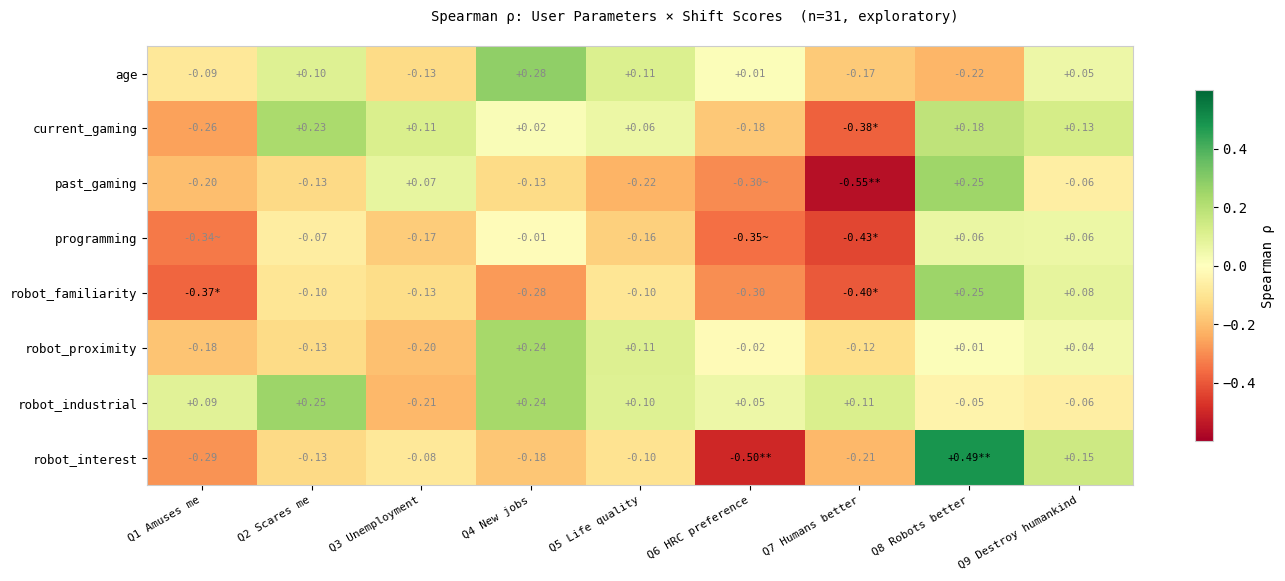

In [37]:
# =============================================================================
# PLOT 1 — Spearman heatmap  (params × questions)
# =============================================================================
 
DARK = '#ffffff'   
SURF = '#f5f5f5'   
SURF2  = '#eeeeee'
BORDER = '#cccccc'
MUTED  = '#888888'
TEXT   = 'black'
 
plt.rcParams.update({
    'figure.facecolor': DARK,   'axes.facecolor': SURF,
    'axes.edgecolor':   BORDER, 'axes.labelcolor': TEXT,
    'xtick.color':      TEXT,   'ytick.color': TEXT,
    'text.color':       TEXT,   'grid.color': BORDER,
    'font.family':      'monospace',
})
 
all_params = CONTINUOUS_PARAMS + LIKERT_PARAMS
rho_m  = np.zeros((len(all_params), len(Q_LABELS)))
praw_m = np.ones((len(all_params), len(Q_LABELS)))
padj_m = np.ones((len(all_params), len(Q_LABELS)))
 
for i, param in enumerate(all_params):
    for j, q in enumerate(Q_LABELS):
        row = sp_df[(sp_df['param'] == param) & (sp_df['question'] == q)]
        if len(row):
            rho_m[i, j]  = row.iloc[0]['stat']
            praw_m[i, j] = row.iloc[0]['p_raw']
            padj_m[i, j] = row.iloc[0]['p_adj']
 
fig, ax = plt.subplots(figsize=(14, 6), facecolor=DARK)
fig.suptitle(
    "Spearman ρ: User Parameters × Shift Scores  (n=31, exploratory)\n",
    #     "Cell: ρ value  |  * p_raw<.05   ** p_raw<.01"
    fontsize=10, color=TEXT, y=0.96)
 
norm_c = TwoSlopeNorm(vmin=-0.6, vcenter=0, vmax=0.6)
im     = ax.imshow(rho_m, cmap=plt.get_cmap('RdYlGn'), norm=norm_c, aspect='auto')
 
for i in range(len(all_params)):
    for j in range(len(Q_LABELS)):
        rho  = rho_m[i, j]
        s_r  = stars(praw_m[i, j])
        s_bh = '[BH]' if padj_m[i, j] <= 0.05 else ''
        # show both raw stars and BH marker
        cell = f"{rho:+.2f}{s_r}"
        if s_bh:
            cell += f"\n{s_bh}"
        txt_color = MUTED if abs(rho) < 0.35 else TEXT
        ax.text(j, i, cell, ha='center', va='center',
                fontsize=7.5, color=txt_color)
 
ax.set_xticks(range(len(Q_LABELS)))
ax.set_xticklabels(Q_LABELS,
                   rotation=30, ha='right', fontsize=8)
ax.set_yticks(range(len(all_params)))
ax.set_yticklabels(all_params, fontsize=9)
plt.colorbar(im, ax=ax, label='Spearman ρ', shrink=0.8)
plt.tight_layout()

plt.savefig('spearman_heatmap.png', dpi=180,
            bbox_inches='tight', facecolor='white')

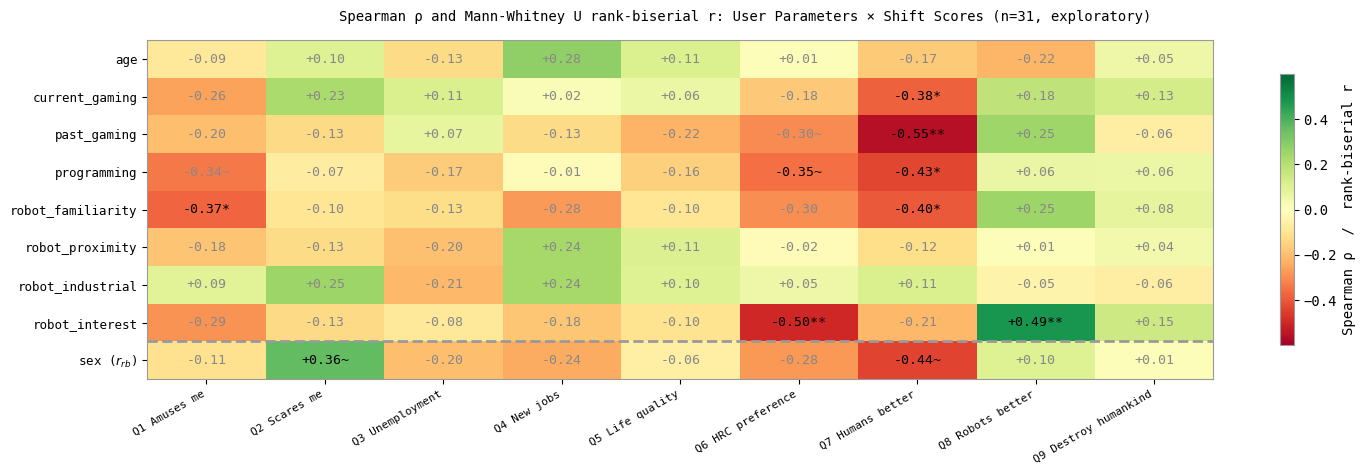

In [52]:
# =============================================================================
# PLOT 1 — Spearman heatmap and Mann-Whitney (params × questions) + sex row
# =============================================================================

DARK = '#ffffff'
SURF = '#f5f5f5'
SURF2  = '#eeeeee'
BORDER = '#9a9a9a'
MUTED  = '#888888'
TEXT   = 'black'

plt.rcParams.update({
    'figure.facecolor': DARK,   'axes.facecolor': SURF,
    'axes.edgecolor':   BORDER, 'axes.labelcolor': TEXT,
    'xtick.color':      TEXT,   'ytick.color': TEXT,
    'text.color':       TEXT,   'grid.color': BORDER,
    'font.family':      'monospace',
})

all_params = CONTINUOUS_PARAMS + LIKERT_PARAMS

# ── Build Spearman matrix ─────────────────────────────────────────────────────
rho_m  = np.zeros((len(all_params), len(Q_LABELS)))
praw_m = np.ones((len(all_params),  len(Q_LABELS)))
padj_m = np.ones((len(all_params),  len(Q_LABELS)))

for i, param in enumerate(all_params):
    for j, q in enumerate(Q_LABELS):
        row = sp_df[(sp_df['param'] == param) & (sp_df['question'] == q)]
        if len(row):
            rho_m[i, j]  = row.iloc[0]['stat']
            praw_m[i, j] = row.iloc[0]['p_raw']
            padj_m[i, j] = row.iloc[0]['p_adj']

# ── Build sex row (Mann-Whitney rank-biserial r) ──────────────────────────────
sex_rho  = np.zeros((1, len(Q_LABELS)))
sex_praw = np.ones((1,  len(Q_LABELS)))
sex_padj = np.ones((1,  len(Q_LABELS)))

for j, q in enumerate(Q_LABELS):
    row = sex_df[(sex_df['param'] == 'sex') & (sex_df['question'] == q)]
    if len(row):
        sex_rho[0, j]  = row.iloc[0]['stat']
        sex_praw[0, j] = row.iloc[0]['p_raw']
        sex_padj[0, j] = row.iloc[0]['p_adj']

# ── Stack matrices: Spearman rows + sex row ───────────────────────────────────
combined_rho  = np.vstack([rho_m,  sex_rho])
combined_praw = np.vstack([praw_m, sex_praw])
combined_padj = np.vstack([padj_m, sex_padj])

n_rows = len(all_params) + 1   # +1 for sex row

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 5), facecolor=DARK)
fig.suptitle(
    "Spearman ρ and Mann-Whitney U rank-biserial r: User Parameters × Shift Scores (n=31, exploratory)\n",
    fontsize=10, color=TEXT, y=0.94)

norm_c = TwoSlopeNorm(vmin=-0.6, vcenter=0, vmax=0.6)
im     = ax.imshow(combined_rho, cmap=plt.get_cmap('RdYlGn'),
                   norm=norm_c, aspect='auto')

# ── Cell annotations ──────────────────────────────────────────────────────────
for i in range(n_rows):
    for j in range(len(Q_LABELS)):
        rho  = combined_rho[i, j]
        s_r  = stars(combined_praw[i, j])
        cell = f"{rho:+.2f}{s_r}"
        txt_color = MUTED if abs(rho) < 0.35 else TEXT
        ax.text(j, i, cell, ha='center', va='center',
                fontsize=9.5, color=txt_color)

# ── Separator line between Spearman rows and sex row ─────────────────────────
ax.axhline(len(all_params) - 0.5, color=BORDER, linewidth=2.0, linestyle='--')

# ── Y-axis labels ─────────────────────────────────────────────────────────────
y_labels = all_params + [r'sex ($r_{rb}$)']
ax.set_yticks(range(n_rows))
ax.set_yticklabels(y_labels, fontsize=9)

# ── X-axis labels ─────────────────────────────────────────────────────────────
ax.set_xticks(range(len(Q_LABELS)))
ax.set_xticklabels(Q_LABELS,
                   rotation=30, ha='right', fontsize=8)

# ── Colorbar ──────────────────────────────────────────────────────────────────
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Spearman ρ  /  rank-biserial r', color=TEXT)
cbar.ax.yaxis.label.set_color(TEXT)
cbar.ax.tick_params(colors=TEXT)

plt.tight_layout()
plt.savefig('spearman_heatmap.png', dpi=180,
            bbox_inches='tight', facecolor='white')

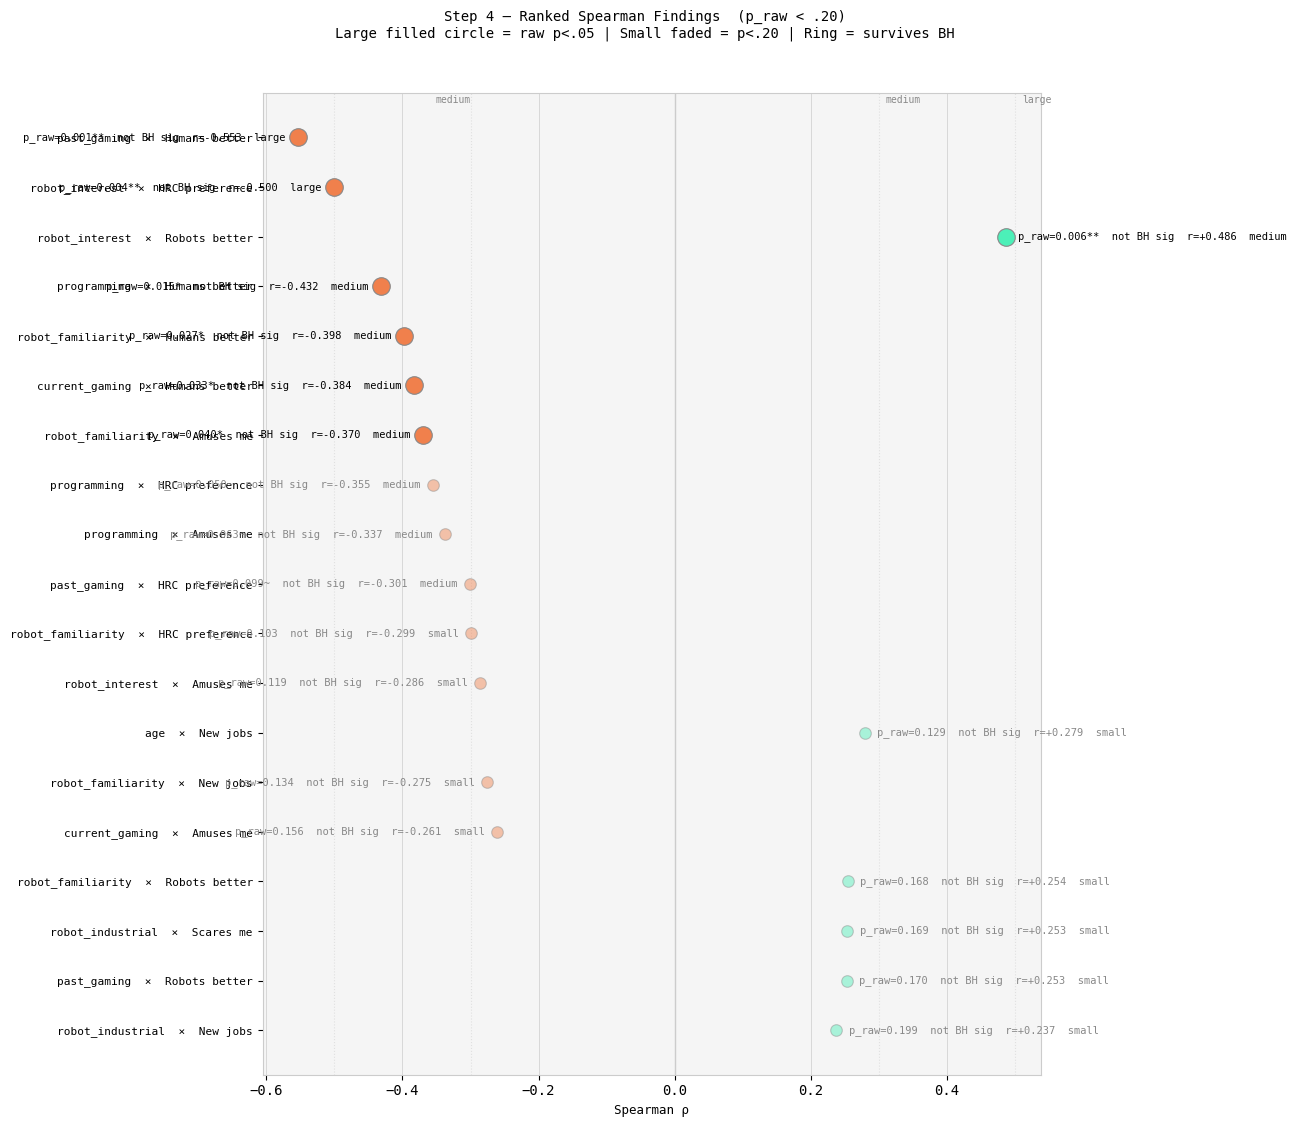

In [27]:
# =============================================================================
# PLOT 2 — Ranked dot plot  (raw p < .20, dual colour by significance type)
# =============================================================================
 
notable_sp = sp_df[sp_df['p_raw'] < 0.20].copy()
notable_sp['effect'] = notable_sp['stat'].apply(effect_label)
notable_sp = notable_sp.sort_values('p_raw').reset_index(drop=True)
 
fig2, ax2 = plt.subplots(
    figsize=(13, max(5, len(notable_sp) * 0.5 + 1.5)), facecolor=DARK)
ax2.set_facecolor(SURF)
fig2.suptitle(
    "Step 4 — Ranked Spearman Findings  (p_raw < .20)\n"
    "Large filled circle = raw p<.05 | Small faded = p<.20 | Ring = survives BH",
    fontsize=10, color=TEXT, y=1.02)
 
for i, row in notable_sp.iterrows():
    rho   = row['stat']
    p_r   = row['p_raw']
    p_a   = row['p_adj']
    color = GREEN if rho > 0 else RED
    size  = 160 if p_r < 0.05 else 70
    alpha = 1.0 if p_r < 0.05 else 0.45
 
    # filled dot
    ax2.scatter(rho, i, c=color, s=size, alpha=alpha,
                edgecolors=MUTED, linewidths=0.8, zorder=3)
    # BH ring (outer circle)
    if p_a <= 0.05:
        ax2.scatter(rho, i, s=size * 2.5, facecolors='none',
                    edgecolors=YELLOW, linewidths=2, zorder=4)
 
    label = (f"p_raw={p_r:.3f}{stars(p_r)}  "
             f"{'p_adj='+f'{p_a:.3f} ← BH sig' if p_a<=0.05 else 'not BH sig'}  "
             f"r={rho:+.3f}  {row['effect']}")
    offset = 0.018 if rho >= 0 else -0.018
    ax2.text(rho + offset, i, label,
             va='center', ha='left' if rho >= 0 else 'right',
             fontsize=7.5, color=TEXT if p_r < 0.05 else MUTED)
 
ax2.set_yticks(range(len(notable_sp)))
ax2.set_yticklabels(
    [f"{r['param']}  ×  {r['question'].split(' ',1)[1]}"
     for _, r in notable_sp.iterrows()],
    fontsize=8)
ax2.axvline(0,     color=BORDER, lw=1)
ax2.axvline(-0.30, color=BORDER, lw=0.8, ls=':', alpha=0.5)
ax2.axvline(+0.30, color=BORDER, lw=0.8, ls=':', alpha=0.5)
ax2.axvline(-0.50, color=BORDER, lw=0.8, ls=':', alpha=0.5)
ax2.axvline(+0.50, color=BORDER, lw=0.8, ls=':', alpha=0.5)
ax2.text( 0.31, -0.7, 'medium', fontsize=7, color=MUTED)
ax2.text( 0.51, -0.7, 'large',  fontsize=7, color=MUTED)
ax2.text(-0.30, -0.7, 'medium', fontsize=7, color=MUTED, ha='right')
ax2.set_xlabel("Spearman ρ", fontsize=9)
ax2.grid(axis='x', zorder=0)
ax2.invert_yaxis()
plt.tight_layout()
 

In the plot above, large filled circles are raw p<.05, faded smaller circles are p<.20, and a yellow ring would appear around anything that survived BH. The threshold lines at ±.30 and ±.50 mark medium and large effect size regions so the reader can visually assess effect magnitude independently of p-values.